# **SegmenterND — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.segmenter_nd import segmenter_nd
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [ ]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
# Load one image and normalize to [0,1] if needed
image = io.read_image(images_path[rand], framework="numpy")

def run_seg(mode, proc="vectorized", fw="numpy", out="numpy", **kwargs):
    @timer(return_result=True, name = mode + "_" + fw + "_" + out)
    def _runner(img):
        return segmenter_nd(
            img,
            segmenter_mode=mode,
            processor_strategy=proc,
            framework=fw,
            output_format=out,
            layout_name="HWC",
            layout_framework="numpy",
            layout_ensured_name="HWC" if fw=="numpy" else "CHW",
            **kwargs
        )
    return _runner

seg_kmeans        = run_seg("kmeans",   proc="vectorized", fw="numpy", num_classes=4, use_channels=True)(image)
seg_otsu          = run_seg("otsu",     proc="vectorized", fw="numpy")(image)
seg_multi         = run_seg("multi",    proc="vectorized", fw="numpy", multi_thresholds=[0.33, 0.66])(image)
seg_rg            = run_seg("region_growing", proc="vectorized", fw="numpy", threshold=0.15, n_seeds=5)(image)
seg_iter          = run_seg("iterative",      proc="vectorized", fw="numpy")(image)
seg_kmeans_torch  = run_seg("kmeans", proc="torch", fw="torch", out="numpy", num_classes=3, use_channels=True)(image)

print("Computed: kmeans, otsu, multi, region_growing, iterative, kmeans(torch).")

Execution time for 'kmeans_numpy_numpy': 2.132 seconds
Execution time for 'otsu_numpy_numpy': 0.373 seconds
Execution time for 'multi_numpy_numpy': 0.249 seconds
Execution time for 'region_growing_numpy_numpy': 95.141 seconds
Execution time for 'iterative_numpy_numpy': 0.314 seconds
Execution time for 'kmeans_torch_numpy': 1.686 seconds
Computed: kmeans, otsu, multi, region_growing, iterative, kmeans(torch).


## Visualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


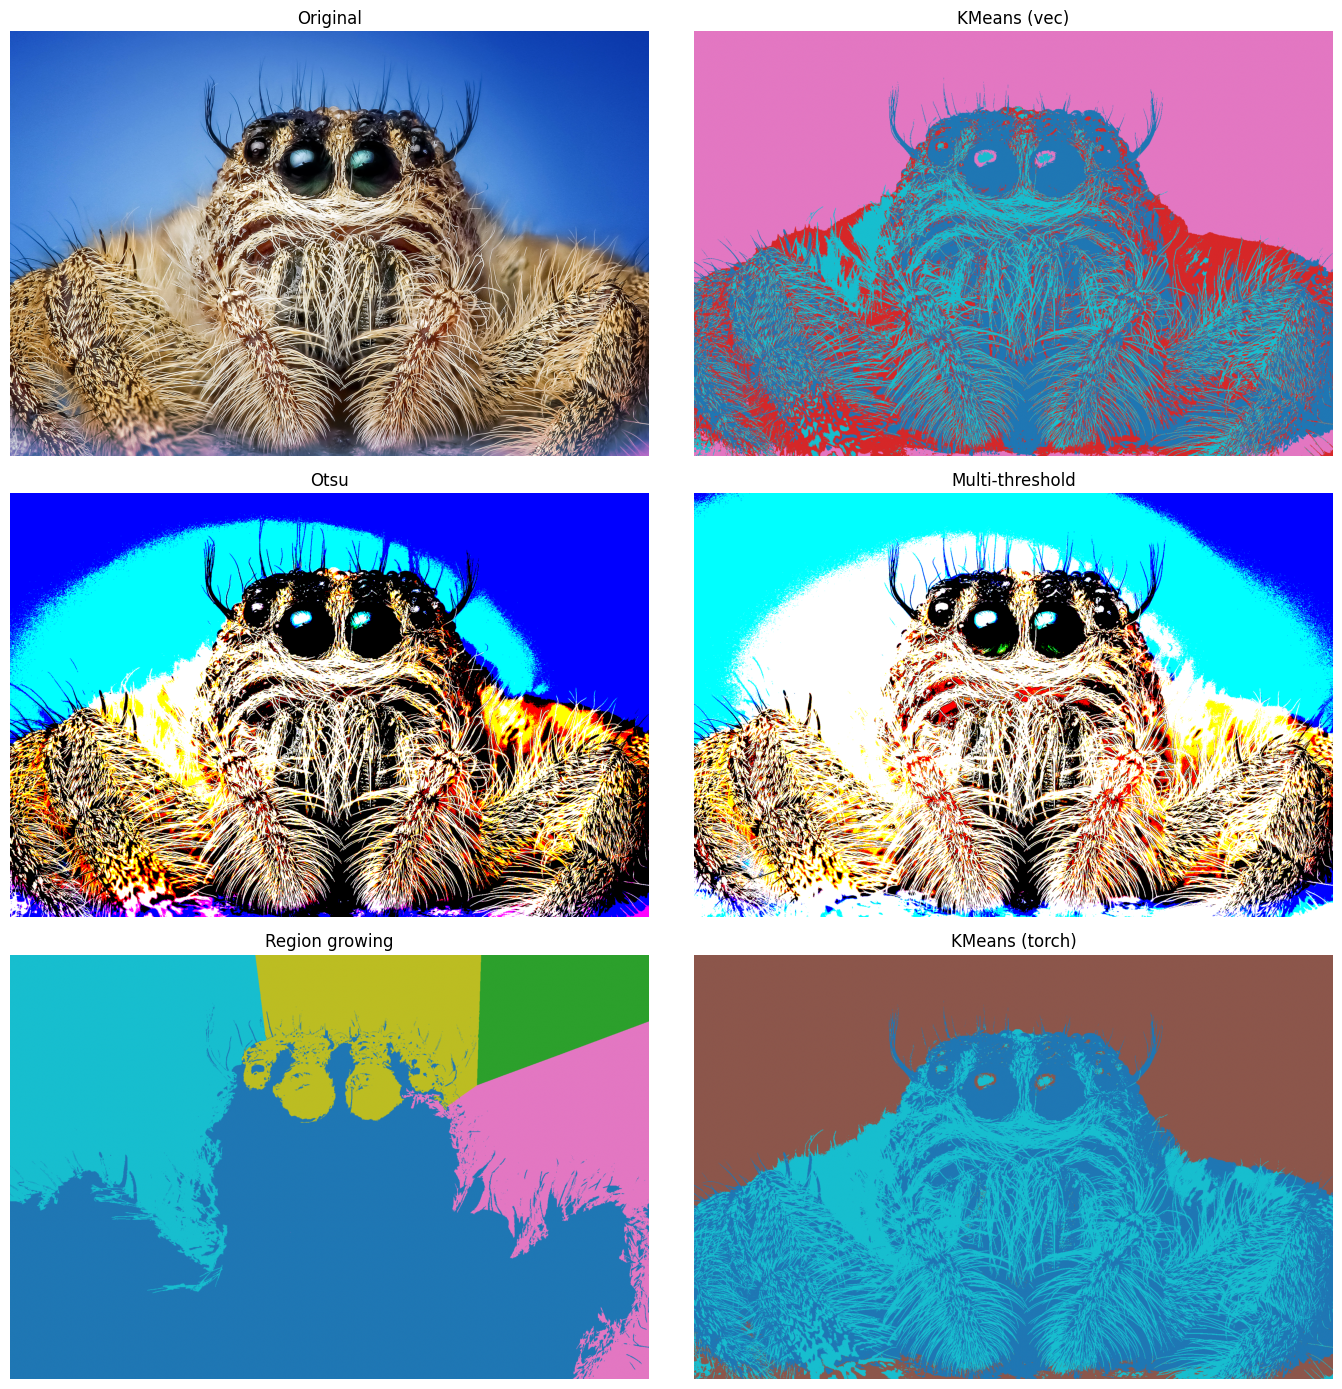

In [5]:
# Simple palette helper for label maps
def prep_for_display(arr):
    arr = np.asarray(arr)
    return arr.astype("float32")

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
show_plane(axes[0,0], image, title="Original", cmap="gray")
show_plane(axes[0,1], prep_for_display(seg_kmeans), title="KMeans (vec)",     cmap="tab10")
show_plane(axes[1,0], prep_for_display(seg_otsu),   title="Otsu",             cmap="binary")
show_plane(axes[1,1], prep_for_display(seg_multi),  title="Multi-threshold",  cmap="tab10")
show_plane(axes[2,0], prep_for_display(seg_rg),     title="Region growing",   cmap="tab10")
show_plane(axes[2,1], prep_for_display(seg_kmeans_torch), title="KMeans (torch)", cmap="tab10")

plt.tight_layout(); plt.show()